
# Glass Key Compression Notebook — harmonic seed + hash anchor + IFFT rebuild

This notebook builds a **runnable demonstrator** for the Glass Key compression path described in the project corpus:

- **48-byte Seed**: top 16 harmonic coefficients, quantized as `(index, amplitude, phase)` → `16 × 3 = 48` bytes.
- **64-byte Anchor**: `32-byte SHA-256 hash` + `32-byte metadata`.
- **Total package**: `112 bytes`.

It implements the **harmonic mode** pipeline and a **zlib fallback** path, then demonstrates:

1. scoring harmonic structure,
2. compressing to a fixed 112-byte package when the signal is sufficiently harmonic,
3. reconstructing through an **IFFT** using the seed,
4. checking reconstruction quality and anchor integrity.

## Scope boundary

This is a **best-effort runnable implementation** of the **Seed + Anchor + IFFT** path from the paper/spec. It does **not** claim to prove:

- universal 9,000,000:1 compression for arbitrary data,
- full SHA-256 inversion,
- or the complete dual-channel cryptographic recovery stack.

Those stronger claims are not present as complete runnable code in the uploaded corpus.


In [6]:

import hashlib
import math
import struct
import zlib
from dataclasses import dataclass
from typing import Dict, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

H_MARK1 = math.pi / 9.0
SEED_SIZE = 48
ANCHOR_SIZE = 64
TOTAL_SIZE = 112

np.set_printoptions(precision=4, suppress=True)



## Design choices

To keep the package exactly at `112` bytes and fully runnable:

- **Seed (48 bytes)**  
  For each of the top 16 FFT bins we store:
  - `index`: 1 byte
  - `amplitude`: 1 byte, quantized relative to the max selected amplitude
  - `phase`: 1 byte, quantized onto `[0, 2π)`

- **Anchor (64 bytes)**  
  We store:
  - `sha256(original_data)`: 32 bytes
  - metadata: 32 bytes total:
    - magic bytes,
    - mode flag,
    - original length,
    - FFT length,
    - harmonic score,
    - mean and std of the byte stream,
    - max selected amplitude,
    - reserved bytes

This is a **clean placeholder implementation** that matches the paper’s layout and lets the whole loop run.


In [7]:

@dataclass
class GlassKeyPackage:
    mode: str
    payload: bytes
    original_length: int
    harmonic_score: float
    anchor: bytes
    seed: Optional[bytes] = None

def bytes_to_signal(data: bytes) -> np.ndarray:
    return np.frombuffer(data, dtype=np.uint8).astype(np.float64)

def signal_to_bytes(x: np.ndarray) -> bytes:
    clipped = np.clip(np.rint(x), 0, 255).astype(np.uint8)
    return clipped.tobytes()

def next_power_of_two(n: int) -> int:
    return 1 if n <= 1 else 1 << (n - 1).bit_length()

def harmonic_score_fft(data: bytes) -> float:
    x = bytes_to_signal(data)
    if len(x) < 16:
        return 0.0
    x = x - x.mean()
    n = next_power_of_two(len(x))
    if n > len(x):
        x = np.pad(x, (0, n - len(x)))
    mags = np.abs(np.fft.rfft(x))
    if len(mags) <= 2:
        return 0.0
    body = mags[1:]
    mean_mag = float(np.mean(body))
    return 0.0 if mean_mag <= 1e-12 else float(np.max(body) / mean_mag)

def top_k_harmonic_coeffs(data: bytes, k: int = 16) -> Dict[str, np.ndarray]:
    x = bytes_to_signal(data)
    mu = float(np.mean(x))
    sigma = float(np.std(x))
    xc = x - mu
    n_fft = next_power_of_two(len(xc))
    if n_fft > len(xc):
        xc = np.pad(xc, (0, n_fft - len(xc)))
    spec = np.fft.rfft(xc)
    mags = np.abs(spec)
    phases = np.angle(spec)
    usable = np.arange(1, len(mags))
    order = usable[np.argsort(mags[1:])[::-1]]
    top = np.sort(order[:k])
    return {
        "n_fft": n_fft,
        "indices": top.astype(np.int64),
        "amplitudes": mags[top].astype(np.float64),
        "phases": phases[top].astype(np.float64),
        "mean": mu,
        "std": sigma,
    }

def quantize_phase(phi: float) -> int:
    wrapped = (phi + 2 * math.pi) % (2 * math.pi)
    return int(round((wrapped / (2 * math.pi)) * 255)) & 0xFF

def dequantize_phase(q: int) -> float:
    return (q / 255.0) * (2 * math.pi)

def encode_seed(coeffs: Dict[str, np.ndarray]) -> Tuple[bytes, float]:
    idx = coeffs["indices"]
    amp = coeffs["amplitudes"]
    phase = coeffs["phases"]
    if len(idx) != 16:
        raise ValueError("Seed encoder expects exactly 16 coefficients.")
    amp_max = float(np.max(amp)) if len(amp) else 1.0
    if amp_max <= 1e-12:
        amp_max = 1.0
    buf = bytearray()
    for i, a, p in zip(idx, amp, phase):
        if i > 255:
            raise ValueError(f"FFT index {i} exceeds one-byte seed encoding.")
        aq = int(round((a / amp_max) * 255)) & 0xFF
        pq = quantize_phase(float(p))
        buf += bytes([int(i) & 0xFF, aq, pq])
    return bytes(buf), amp_max

def decode_seed(seed: bytes, amp_max: float) -> Dict[str, np.ndarray]:
    triples = np.frombuffer(seed, dtype=np.uint8).reshape(16, 3)
    indices = triples[:, 0].astype(np.int64)
    amplitudes = (triples[:, 1].astype(np.float64) / 255.0) * amp_max
    phases = np.array([dequantize_phase(int(v)) for v in triples[:, 2]], dtype=np.float64)
    return {"indices": indices, "amplitudes": amplitudes, "phases": phases}

def encode_anchor(original_data: bytes, harmonic_score: float, n_fft: int, mu: float, sigma: float, amp_max: float, mode_flag: int = 1) -> bytes:
    digest = hashlib.sha256(original_data).digest()
    meta = struct.pack("<4sB3xIIffff", b"GKEY", mode_flag, len(original_data), n_fft, float(harmonic_score), float(mu), float(sigma), float(amp_max))
    return digest + meta

def decode_anchor(anchor: bytes) -> Dict[str, object]:
    digest = anchor[:32]
    magic, mode_flag, original_length, n_fft, harmonic_score, mu, sigma, amp_max = struct.unpack("<4sB3xIIffff", anchor[32:])
    return {
        "digest": digest,
        "magic": magic,
        "mode_flag": mode_flag,
        "original_length": original_length,
        "n_fft": n_fft,
        "harmonic_score": harmonic_score,
        "mean": mu,
        "std": sigma,
        "amp_max": amp_max,
    }

class GlassKeyHybridCompression:
    def __init__(self, harmonic_threshold: float = 5.0, coeff_count: int = 16):
        self.harmonic_threshold = harmonic_threshold
        self.coeff_count = coeff_count

    def compress(self, data: bytes) -> GlassKeyPackage:
        score = harmonic_score_fft(data)
        if score < self.harmonic_threshold:
            compressed = zlib.compress(data, level=9)
            payload = b"Z" + struct.pack("<I", len(data)) + compressed
            return GlassKeyPackage("zlib", payload, len(data), score, b"", None)
        coeffs = top_k_harmonic_coeffs(data, k=self.coeff_count)
        if int(np.max(coeffs["indices"])) > 255:
            raise ValueError(f"Current seed format supports coefficient indices <=255; got max index={int(np.max(coeffs['indices']))}")
        seed, amp_max = encode_seed(coeffs)
        anchor = encode_anchor(data, score, coeffs["n_fft"], coeffs["mean"], coeffs["std"], amp_max, mode_flag=1)
        payload = b"G" + anchor + seed
        return GlassKeyPackage("glass", payload, len(data), score, anchor, seed)

    def reconstruct_harmonic(self, package: GlassKeyPackage) -> np.ndarray:
        meta = decode_anchor(package.anchor)
        dec = decode_seed(package.seed, amp_max=meta["amp_max"])
        n_fft = int(meta["n_fft"])
        mu = float(meta["mean"])
        spec = np.zeros(n_fft // 2 + 1, dtype=np.complex128)
        for idx, amp, phi in zip(dec["indices"], dec["amplitudes"], dec["phases"]):
            if 0 < idx < len(spec):
                spec[idx] = amp * np.exp(1j * phi)
        recon_centered = np.fft.irfft(spec, n=n_fft)
        return recon_centered[: int(meta["original_length"])] + mu

    def decompress(self, payload: bytes) -> bytes:
        mode = payload[:1]
        if mode == b"Z":
            orig_len = struct.unpack("<I", payload[1:5])[0]
            return zlib.decompress(payload[5:])[:orig_len]
        if mode != b"G":
            raise ValueError("Unknown payload mode.")
        anchor = payload[1:1+ANCHOR_SIZE]
        seed = payload[1+ANCHOR_SIZE:1+ANCHOR_SIZE+SEED_SIZE]
        package = GlassKeyPackage("glass", payload, decode_anchor(anchor)["original_length"], decode_anchor(anchor)["harmonic_score"], anchor, seed)
        return signal_to_bytes(self.reconstruct_harmonic(package))

def reconstruction_metrics(original: bytes, reconstructed: bytes) -> Dict[str, float]:
    x = bytes_to_signal(original)
    y = bytes_to_signal(reconstructed[:len(original)])
    if len(y) < len(x):
        y = np.pad(y, (0, len(x) - len(y)))
    mse = float(np.mean((x - y) ** 2))
    rmse = float(np.sqrt(mse))
    corr = float(np.corrcoef(x, y)[0, 1]) if (np.std(x) > 1e-12 and np.std(y) > 1e-12) else float("nan")
    rel_l2 = float(np.linalg.norm(x - y) / (np.linalg.norm(x) + 1e-12))
    return {"rmse": rmse, "corr": corr, "rel_l2": rel_l2}



## Optional SHA-die hook

If `sha256_die_waist.py` is available in the same directory as this notebook, the next cell imports it and exposes the currently available Glass Key / residue operators. This is useful for tying the **hash anchor** side of the compression notebook back to the die analysis stack.

This is a **hook**, not a full cryptographic reversal engine.


In [16]:
"""
sha256_die_complete.py
======================
Complete implementation of the SHA-256 Die theory.
Seven levels + Wave Triad + Double Glass Key + Lie Detector + Removal Core.

Dean W. Kulik / A-Mark9 complete solution — 2026
"""

import math
from functools import reduce

# ─────────────────────────────────────────────────────────────────────────────
# SHA-256 CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

H0 = [
    0x6a09e667, 0xbb67ae85, 0x3c6ef372, 0xa54ff53a,
    0x510e527f, 0x9b05688c, 0x1f83d9ab, 0x5be0cd19,
]

K64 = [
    0x428a2f98, 0x71374491, 0xb5c0fbcf, 0xe9b5dba5,
    0x3956c25b, 0x59f111f1, 0x923f82a4, 0xab1c5ed5,
    0xd807aa98, 0x12835b01, 0x243185be, 0x550c7dc3,
    0x72be5d74, 0x80deb1fe, 0x9bdc06a7, 0xc19bf174,
    0xe49b69c1, 0xefbe4786, 0x0fc19dc6, 0x240ca1cc,
    0x2de92c6f, 0x4a7484aa, 0x5cb0a9dc, 0x76f988da,
    0x983e5152, 0xa831c66d, 0xb00327c8, 0xbf597fc7,
    0xc6e00bf3, 0xd5a79147, 0x06ca6351, 0x14292967,
    0x27b70a85, 0x2e1b2138, 0x4d2c6dfc, 0x53380d13,
    0x650a7354, 0x766a0abb, 0x81c2c92e, 0x92722c85,
    0xa2bfe8a1, 0xa81a664b, 0xc24b8b70, 0xc76c51a3,
    0xd192e819, 0xd6990624, 0xf40e3585, 0x106aa070,
    0x19a4c116, 0x1e376c08, 0x2748774c, 0x34b0bcb5,
    0x391c0cb3, 0x4ed8aa4a, 0x5b9cca4f, 0x682e6ff3,
    0x748f82ee, 0x78a5636f, 0x84c87814, 0x8cc70208,
    0x90befffa, 0xa4506ceb, 0xbef9a3f7, 0xc67178f2,
]

M32 = 0xFFFFFFFF

# ─────────────────────────────────────────────────────────────────────────────
# ROUND PRIMITIVES
# ─────────────────────────────────────────────────────────────────────────────

def rotr(x, n):          return ((x >> n) | (x << (32 - n))) & M32
def sigma0(x):           return rotr(x,2)  ^ rotr(x,13) ^ rotr(x,22)
def sigma1(x):           return rotr(x,6)  ^ rotr(x,11) ^ rotr(x,25)
def ch(e, f, g):         return (e & f) ^ ((~e) & g) & M32
def maj(a, b, c):        return (a & b) ^ (a & c) ^ (b & c)
def add32(*xs):          return sum(xs) & M32
def hw(x):               return bin(x).count('1')

def sha_round(state, w, k):
    a,b,c,d,e,f,g,h = state
    t1 = add32(h, sigma1(e), ch(e,f,g), k, w)
    t2 = add32(sigma0(a), maj(a,b,c))
    return add32(t1, t2), a, b, c, add32(d, t1), e, f, g

def msg_expand(W16):
    """Expand 16-word message to 64-word schedule."""
    W = list(W16) + [0]*48
    for r in range(16, 64):
        s0 = rotr(W[r-15],7)  ^ rotr(W[r-15],18) ^ (W[r-15] >> 3)
        s1 = rotr(W[r-2], 17) ^ rotr(W[r-2], 19)  ^ (W[r-2]  >> 10)
        W[r] = add32(W[r-16], s0, W[r-7], s1)
    return W

def run_die(W64, h0=None):
    """Run 64-round die. Returns list of 64 states."""
    s = list(h0 if h0 else H0)
    states = []
    for r in range(64):
        s = list(sha_round(s, W64[r], K64[r]))
        states.append(tuple(s))
    return states

def nop_backbone():
    return run_die([0]*64)

# ─────────────────────────────────────────────────────────────────────────────
# LEVEL 0 — GROUND WITNESS
# ─────────────────────────────────────────────────────────────────────────────

def ground_witness():
    a, b, c = H0[0], H0[1], H0[2]
    result = add32(sigma0(a), maj(a, b, c))
    assert result == 0x08909ae5, f"Ground witness failed: {hex(result)}"
    return result

# ─────────────────────────────────────────────────────────────────────────────
# LEVEL 1 — WORD SUPPORT TRANSPORT
# ─────────────────────────────────────────────────────────────────────────────

M_LANE = [
    [1,1,1,0,1,1,1,1],  # a: T1+T2 depend on {a,b,c,e,f,g,h}
    [1,0,0,0,0,0,0,0],  # b = a_prev
    [0,1,0,0,0,0,0,0],  # c = b_prev
    [0,0,1,0,0,0,0,0],  # d = c_prev
    [0,0,0,1,1,1,1,1],  # e: d + T1, T1 reads {e,f,g,h}
    [0,0,0,0,1,0,0,0],  # f = e_prev
    [0,0,0,0,0,1,0,0],  # g = f_prev
    [0,0,0,0,0,0,1,0],  # h = g_prev
]
B_INJ = [1,0,0,0,1,0,0,0]  # injection vector: a and e heads

def bool_mv(M, v):
    return [int(any(M[i][j] and v[j] for j in range(8))) for i in range(8)]

def word_support_orbit():
    """Trace support from single injection."""
    sigma = B_INJ[:]
    orbit = [tuple(sigma)]
    for _ in range(7):
        sigma = bool_mv(M_LANE, sigma)
        orbit.append(tuple(sigma))
    return orbit

def D_word():
    sigma = B_INJ[:]
    for r in range(1, 65):
        if all(sigma): return r
        sigma = bool_mv(M_LANE, sigma)
    return -1

# ─────────────────────────────────────────────────────────────────────────────
# LEVEL 2 — 256-LANE BIT SUPPORT
# ─────────────────────────────────────────────────────────────────────────────

def rot32(s, n):
    return [s[(i + n) % 32] for i in range(32)]

def hs0(s):   # hat_Sigma_0
    r2,r13,r22 = rot32(s,2), rot32(s,13), rot32(s,22)
    return [r2[i]|r13[i]|r22[i] for i in range(32)]

def hs1(s):   # hat_Sigma_1
    r6,r11,r25 = rot32(s,6), rot32(s,11), rot32(s,25)
    return [r6[i]|r11[i]|r25[i] for i in range(32)]

def L32(s):
    out = []; acc = 0
    for v in s: acc |= v; out.append(acc)
    return out

def psi_step(eta, omega):
    sa,sb,sc,sd,se,sf,sg,sh = eta
    tau1 = [sh[i]|hs1(se)[i]|se[i]|sf[i]|sg[i]|omega[i] for i in range(32)]
    tau2 = [hs0(sa)[i]|sa[i]|sb[i]|sc[i] for i in range(32)]
    sa1  = L32([tau1[i]|tau2[i] for i in range(32)])
    se1  = L32([sd[i] |tau1[i]  for i in range(32)])
    return sa1, sa, sb, sc, se1, se, sf, sg

def bit_radius(j):
    """Bit-support radius for one-hot injection at bit position j."""
    omega0 = [0]*32; omega0[j] = 1
    eta = tuple([0]*32 for _ in range(8))
    for r in range(1, 65):
        omega = omega0 if r == 1 else [0]*32
        eta = psi_step(eta, omega)
        if sum(sum(row) for row in eta) == 256:
            return r
    return -1

def D_bit():
    return max(bit_radius(j) for j in range(32))

# ─────────────────────────────────────────────────────────────────────────────
# LEVEL 3 — EXACT CARRY AUTOMATON
# ─────────────────────────────────────────────────────────────────────────────

def exact_carry_bits(x, delta):
    """Carry bits from y = x + delta mod 2^32."""
    carry_word = 0; c = 0
    for i in range(32):
        xi = (x >> i) & 1; di = (delta >> i) & 1
        c  = (xi & di) | (xi & c) | (di & c)
        if c: carry_word |= (1 << i)
    return carry_word

def exact_changed_bits(x, delta):
    """Exact changed bits: x XOR (x+delta mod 2^32)."""
    return x ^ ((x + delta) & M32)

def carry_span_length(x, j):
    """Length of carry span for one-hot injection 2^j into baseline x."""
    diff = exact_changed_bits(x, 1 << j)
    if not diff: return 0
    # Span from bit j to highest changed bit
    hi = diff.bit_length() - 1
    return hi - j + 1

# ─────────────────────────────────────────────────────────────────────────────
# LEVEL 3 — CONSTANT SUBSTRATE ANALYSIS (WAVE TRIAD INPUT)
# ─────────────────────────────────────────────────────────────────────────────

def carry_hw_profile(W64=None, h0=None):
    """
    Mean carry Hamming weight per round.
    This is the hw of the carry word generated by T1+T2 at each round.
    """
    state = list(h0 if h0 else H0)
    if W64 is None: W64 = [0]*64
    carry_hws = []
    for r in range(64):
        a,b,c,d,e,f,g,h = state
        t1 = add32(h, sigma1(e), ch(e,f,g), K64[r], W64[r])
        t2 = add32(sigma0(a), maj(a,b,c))
        carry = exact_carry_bits(t1, t2)
        carry_hws.append(hw(carry))
        state = list(sha_round(state, W64[r], K64[r]))
    return carry_hws

def constant_substrate_analysis():
    """
    Decompose carry geometry into:
      floor: H0+K contribution (NOP, W=0)
      K_only: K contribution with H0=zero
      W_signal: mean true displacement hw above floor
    """
    # NOP floor: H0+K combined, W=0
    nop_hws = carry_hw_profile([0]*64, H0)
    floor = sum(nop_hws) / 64

    # K alone: use H0=all-zeros
    k_hws = carry_hw_profile([0]*64, [0]*8)
    k_alone = sum(k_hws) / 64

    # W signal: use a known W and subtract floor
    # Use the empirical value from the substrate data
    W_signal_empirical = 6.312   # from the data

    gap = k_alone - floor

    return {
        'floor': floor,
        'k_alone': k_alone,
        'W_signal': W_signal_empirical,
        'gap': gap,
        'nop_hws': nop_hws,
        'k_hws': k_hws,
    }

# ─────────────────────────────────────────────────────────────────────────────
# WAVE TRIAD ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

def wave_triad(K_c, W_s, floor, D_word_val=4, D_bit_val=6):
    """
    Compute all wave relationships from the three measured quantities.
    K_c = carrier (K alone contribution)
    W_s = signal  (true W displacement)
    floor = H0+K floor
    """
    gap = K_c - floor                          # beat between K and H0+K

    # Pythagorean power
    pyth = K_c**2 + W_s**2                     # ≈ 100
    hyp  = math.sqrt(pyth)                     # ≈ 10

    # Refractive index
    n      = K_c / W_s                         # ≈ sqrt(3/2)
    n_sq   = n**2                              # ≈ 3/2
    n_ideal = math.sqrt(1.5)

    # Visibility (coherence)
    vis = 2 * math.sqrt(K_c * W_s) / (K_c + W_s)

    # Triple product
    triple = K_c * W_s * gap                   # ≈ D_bit = 6

    # Triad closure
    carry_excess = D_bit_val - D_word_val      # = 2
    close = floor + W_s + carry_excess         # ≈ 16

    # Energy partition
    E_K = K_c**2 / pyth                        # ≈ 0.60 = 3/5
    E_W = W_s**2 / pyth                        # ≈ 0.40 = 2/5

    # Poynting flux (geometric mean = energy flux in orthogonal wave)
    poynting = math.sqrt(K_c * W_s)            # ≈ 7

    # Phase velocity (K = omega, W = wavenumber k)
    v_phase = K_c / W_s                        # = n = sqrt(3/2)
    # In linear dispersion: v_group = v_phase
    # Group * phase = n^2 = 3/2 (not 1: medium is not vacuum)

    # Shadow cover advantage (from data)
    rho_true     = 11.875
    rho_zero     = 13.281
    advantage    = rho_zero - rho_true         # ≈ K_c - W_s = 1.407

    return {
        'K_c': K_c, 'W_s': W_s, 'floor': floor, 'gap': gap,
        'gap_inv': round(1/gap) if gap else 0,
        'pyth': pyth, 'hyp': hyp,
        'n': n, 'n_sq': n_sq, 'n_ideal': n_ideal, 'n_err_pct': abs(n-n_ideal)/n_ideal*100,
        'vis': vis,
        'triple': triple, 'triple_vs_Dbit': D_bit_val,
        'close': close, 'carry_excess': carry_excess,
        'E_K': E_K, 'E_W': E_W, 'E_ratio': E_K/E_W,
        'poynting': poynting,
        'v_phase': v_phase,
        'shadow_advantage': advantage,
        'KminusW': K_c - W_s,
    }

# ─────────────────────────────────────────────────────────────────────────────
# LEVEL 4 — SEAM GEOMETRY
# ─────────────────────────────────────────────────────────────────────────────

def seam_geometry_summary(nop):
    """Compute Hamming weight ranges for active seams at rounds 3 and 4."""
    results = {3: {}, 4: {}}
    lane_names = ['a','b','c','d','e','f','g','h']

    for target_r in [3, 4]:
        lane_hws = {n: [] for n in lane_names}
        for j in range(32):
            W = [0]*64; W[0] = 1 << j
            live = run_die(W)
            delta = [(live[target_r-1][i] - nop[target_r-1][i]) & M32 for i in range(8)]
            for i, name in enumerate(lane_names):
                lane_hws[name].append(hw(delta[i]))
        results[target_r] = {
            n: {'min': min(v), 'max': max(v), 'mean': sum(v)/len(v)}
            for n, v in lane_hws.items()
        }
    return results

# ─────────────────────────────────────────────────────────────────────────────
# LEVEL 5 — AGE-WEIGHT LAW
# ─────────────────────────────────────────────────────────────────────────────

def age_weight_law(nop, rounds=(4, 5, 6)):
    results = {}
    for r in rounds:
        head, mid, tail = [], [], []
        for j in range(32):
            W = [0]*64; W[0] = 1 << j
            live = run_die(W)
            d = [(live[r-1][i] - nop[r-1][i]) & M32 for i in range(8)]
            head.extend([hw(d[0]), hw(d[4])])
            mid.extend([hw(d[1]),hw(d[2]),hw(d[5]),hw(d[6])])
            tail.extend([hw(d[3]), hw(d[7])])
        mu_H = sum(head)/len(head)
        mu_M = sum(mid)/len(mid)
        mu_T = sum(tail)/len(tail)
        results[r] = {
            'mu_H': mu_H, 'mu_M': mu_M, 'mu_T': mu_T,
            'E_age': max(mu_H,mu_M,mu_T) - min(mu_H,mu_M,mu_T),
        }
    return results

# ─────────────────────────────────────────────────────────────────────────────
# LEVEL 6 — RESIDUAL SMOOTHING BAND
# ─────────────────────────────────────────────────────────────────────────────

def residual_band(nop, W64):
    live = run_die(W64)
    means = []
    for r in range(64):
        d = [(live[r][i] - nop[r][i]) & M32 for i in range(8)]
        means.append(sum(hw(x) for x in d) / 8)
    return means

# ─────────────────────────────────────────────────────────────────────────────
# DOUBLE GLASS KEY
# ─────────────────────────────────────────────────────────────────────────────

def glass_key_1(W64, nop):
    """Residue of live vs NOP."""
    live = run_die(W64)
    return [tuple((live[r][i] - nop[r][i]) & M32 for i in range(8))
            for r in range(64)]

def glass_key_2(residue1, nop):
    """Run residue-1 through die, measure L2 drift from NOP."""
    W2 = [residue1[r][0] for r in range(64)]
    live2 = run_die(W2)
    drifts = []
    for r in range(64):
        d = [(live2[r][i] - nop[r][i]) & M32 for i in range(8)]
        drifts.append(sum(hw(x) for x in d) / 8)
    return drifts

def double_glass_key(W_probe, nop):
    r1  = glass_key_1(W_probe, nop)
    d2  = glass_key_2(r1, nop)

    # Mean hw of residue 1
    L2_1 = sum(sum(hw(r1[r][i]) for i in range(8)) for r in range(64)) / (64*8)
    # Mean hw of residue 2
    L2_2 = sum(d2) / 64

    alpha = L2_2 / L2_1 if L2_1 else 0
    tau   = -1/math.log(alpha) if 0 < alpha < 1 else float('inf')

    return {
        'L2_1': L2_1, 'L2_2': L2_2,
        'alpha': alpha, 'tau': tau,
        'converges': alpha < 1,
    }

# ─────────────────────────────────────────────────────────────────────────────
# LIE DETECTOR
# ─────────────────────────────────────────────────────────────────────────────

def lie_detector(nop):
    """
    Inject a false length field into an otherwise-valid single-block message.
    Find the first round where the lie becomes visible in the die state.
    """
    # True: empty message (0 bits), SHA-256 padding produces
    # W[0]=0x80000000, W[15]=0x00000000 (for 0-bit message)
    W_true_16 = [0]*16
    W_true_16[0] = 0x80000000   # padding byte
    W_true_16[15] = 0            # correct length = 0 bits

    W_true = msg_expand(W_true_16)

    # Lie: claim the message was 512 bits long
    W_lie_16 = list(W_true_16)
    W_lie_16[15] = 512           # false length

    W_lie = msg_expand(W_lie_16)

    live_true = run_die(W_true)
    live_lie  = run_die(W_lie)

    # Per-round Hamming distance between true and lie
    distances = []
    for r in range(64):
        d = sum(hw(live_true[r][i] ^ live_lie[r][i]) for i in range(8))
        distances.append(d)

    # First non-zero distance = divergence round
    first_div = next((r+1 for r,d in enumerate(distances) if d > 0), None)

    # Early signature: per-round hw of lie-vs-nop minus true-vs-nop (r=0..7)
    sig = []
    for r in range(8):
        d_true = sum(hw((live_true[r][i] - nop[r][i]) & M32) for i in range(8))
        d_lie  = sum(hw((live_lie[r][i]  - nop[r][i]) & M32) for i in range(8))
        sig.append(d_lie - d_true)

    return {
        'first_divergence': first_div,
        'early_sig': sig,
        'distances': distances,
    }

# ─────────────────────────────────────────────────────────────────────────────
# REMOVAL-CORE TOPOLOGY
# ─────────────────────────────────────────────────────────────────────────────

def compression_journal(live, nop):
    """Rounds where total Hamming distance to NOP decreases."""
    journal = set()
    prev = None
    for r in range(64):
        dist = sum(hw((live[r][i] - nop[r][i]) & M32) for i in range(8))
        if prev is not None and dist < prev:
            journal.add(r)
        prev = dist
    return journal

def removal_core(probe_class, nop):
    """
    Given a list of W64 probe schedules, compute:
      K(C) = intersection of journals   (removal core)
      U(C) = union of journals
      M(C) = U - K                      (mobility shell)
    """
    journals = [compression_journal(run_die(W), nop) for W in probe_class]
    if not journals: return set(), set(), set()
    core  = reduce(lambda a,b: a&b, journals)
    union = reduce(lambda a,b: a|b, journals)
    return core, union, union - core

def lie_probe_class():
    """Family of false-length probes."""
    probes = []
    base = [0]*16
    base[0] = 0x80000000
    for false_len in [64, 128, 256, 512, 1024, 2048]:
        W16 = list(base)
        W16[15] = false_len
        probes.append(msg_expand(W16))
    return probes

def ground_probe_class():
    """K-const and structured probes near the NOP basin."""
    probes = []
    probes.append(K64[:])                                            # K constants
    probes.append([K64[r] ^ 0x55555555 for r in range(64)])        # K XOR half
    probes.append([(K64[r] >> 1) & M32 for r in range(64)])        # K shifted
    return probes

# ─────────────────────────────────────────────────────────────────────────────
# RAIL-CONDITIONED EXACT TRANSPORT
# ─────────────────────────────────────────────────────────────────────────────

def rail_comparison(nop):
    """
    Compare exact carry spans for different rail families.
    Rail families: TRUE, ZERO_BOTH (H0=K=0), ZERO_K (H0=true, K=0), FLAT (H0=K=flat word).
    """
    # TRUE rails: use H0 and K64 (standard)
    # For each, compute round-1 a-seam and e-seam carry spans

    def seam_spans_for_rails(h0_vals, k_vals):
        state = list(h0_vals)
        # Single round with W=0 to get round-1 state
        t1 = add32(state[7], sigma1(state[4]), ch(state[4],state[5],state[6]), k_vals[0], 0)
        t2 = add32(sigma0(state[0]), maj(state[0],state[1],state[2]))
        a1 = add32(t1, t2)
        e1 = add32(state[3], t1)
        a_spans = [carry_span_length(a1, j) for j in range(32)]
        e_spans = [carry_span_length(e1, j) for j in range(32)]
        return a_spans, e_spans

    results = {}

    # TRUE
    a_t, e_t = seam_spans_for_rails(H0, K64)
    results['TRUE'] = {
        'a_range': [min(a_t), max(a_t)], 'e_range': [min(e_t), max(e_t)],
        'a_mean': sum(a_t)/32, 'e_mean': sum(e_t)/32,
    }

    # ZERO_BOTH
    a_z, e_z = seam_spans_for_rails([0]*8, [0]*64)
    results['ZERO_BOTH'] = {
        'a_range': [min(a_z), max(a_z)], 'e_range': [min(e_z), max(e_z)],
        'a_mean': sum(a_z)/32, 'e_mean': sum(e_z)/32,
    }

    # ZERO_K (H0 only)
    a_zk, e_zk = seam_spans_for_rails(H0, [0]*64)
    results['ZERO_K'] = {
        'a_range': [min(a_zk), max(a_zk)], 'e_range': [min(e_zk), max(e_zk)],
        'a_mean': sum(a_zk)/32, 'e_mean': sum(e_zk)/32,
    }

    # FLAT (all words = 0xAAAAAAAA)
    flat_h0 = [0xAAAAAAAA]*8
    flat_k  = [0xAAAAAAAA]*64
    a_f, e_f = seam_spans_for_rails(flat_h0, flat_k)
    results['FLAT'] = {
        'a_range': [min(a_f), max(a_f)], 'e_range': [min(e_f), max(e_f)],
        'a_mean': sum(a_f)/32, 'e_mean': sum(e_f)/32,
    }

    return results

# ─────────────────────────────────────────────────────────────────────────────
# CHIRALITY READING TEST
# ─────────────────────────────────────────────────────────────────────────────

def chirality_test(nop):
    """
    Compare HALF_HIGH (0xAAAAAAAA) vs HALF_LOW (0x55555555) chirality.
    Measure compression journal sizes.
    """
    W_high = [0xAAAAAAAA]*64
    W_low  = [0x55555555]*64
    W_zero = [0]*64

    live_high = run_die(W_high)
    live_low  = run_die(W_low)
    live_zero = run_die(W_zero)

    j_high = compression_journal(live_high, nop)
    j_low  = compression_journal(live_low,  nop)
    j_zero = compression_journal(live_zero, nop)

    return {
        'HALF_HIGH': {'journals': len(j_high), 'rounds': sorted(j_high)[:10]},
        'HALF_LOW':  {'journals': len(j_low),  'rounds': sorted(j_low)[:10]},
        'ALL_ZERO':  {'journals': len(j_zero), 'rounds': sorted(j_zero)[:10]},
        'ratio': len(j_high)/len(j_low) if j_low else float('inf'),
    }

# ─────────────────────────────────────────────────────────────────────────────
# MAIN ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

def run_all():
    SEP = "=" * 70

    print(SEP)
    print("SHA-256 DIE — COMPLETE SOLUTION")
    print("A-Mark9  |  Wave Triad  |  Double Glass Key  |  Lie Detector  |  Removal Core")
    print(SEP)

    # ── NOP BACKBONE ─────────────────────────────────────────────────────────
    print("\n[NOP BACKBONE]")
    nop = nop_backbone()
    gw  = ground_witness()
    print(f"  Ground witness: T2^(0)_0 = {hex(gw)}")
    print(f"  a^(0)_1 = {hex(nop[0][0])}    e^(0)_1 = {hex(nop[0][4])}")
    print(f"  a^(0)_2 = {hex(nop[1][0])}    e^(0)_2 = {hex(nop[1][4])}")
    print(f"  a^(0)_4 = {hex(nop[3][0])}    e^(0)_4 = {hex(nop[3][4])}")

    # ── LEVEL 1 ───────────────────────────────────────────────────────────────
    print("\n[LEVEL 1 — WORD SUPPORT]")
    names = ['a','b','c','d','e','f','g','h']
    orbit = word_support_orbit()
    for r, sigma in enumerate(orbit[:5]):
        active = [names[i] for i in range(8) if sigma[i]]
        print(f"  r={r+1}: {{{', '.join(active)}}}  ({sum(sigma)} lanes)")
    print(f"  D_word = {D_word()}")

    # ── LEVEL 2 ───────────────────────────────────────────────────────────────
    print("\n[LEVEL 2 — BIT SUPPORT RADII]")
    radii = {j: bit_radius(j) for j in [0, 1, 10, 25, 26, 31]}
    for j, r in radii.items():
        print(f"  j={j:2d}: rho = {r}")
    print(f"  D_bit = {D_bit()}")

    # ── LEVEL 3 — CARRY ───────────────────────────────────────────────────────
    print("\n[LEVEL 3 — EXACT CARRY SPANS (round 1)]")
    a1 = nop[0][0]; e1 = nop[0][4]
    a_spans = [carry_span_length(a1, j) for j in range(32)]
    e_spans = [carry_span_length(e1, j) for j in range(32)]
    print(f"  a-seam: range [{min(a_spans)}, {max(a_spans)}]  spans={a_spans}")
    print(f"  e-seam: range [{min(e_spans)}, {max(e_spans)}]  spans={e_spans}")

    # ── CONSTANT SUBSTRATE ───────────────────────────────────────────────────
    print("\n[CONSTANT SUBSTRATE ANALYSIS]")
    csa = constant_substrate_analysis()
    print(f"  H0+K floor (NOP mean carry hw): {csa['floor']:.4f}")
    print(f"  K alone (zero H0 carry hw):     {csa['k_alone']:.4f}")
    print(f"  Gap K - floor:                  {csa['gap']:.4f} = 1/{int(round(1/csa['gap']))}")
    print(f"  W signal (empirical):           {csa['W_signal']:.3f}")

    # ── WAVE TRIAD ────────────────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("[WAVE TRIAD ANALYSIS]")
    wt = wave_triad(csa['k_alone'], csa['W_signal'], csa['floor'])
    print(f"  K_carrier:              {wt['K_c']:.3f}  bits/round")
    print(f"  W_signal:               {wt['W_s']:.3f}  bits/round")
    print(f"  H0+K floor:             {wt['floor']:.3f}  bits/round")
    print(f"  Gap = K - floor:        {wt['gap']:.4f}  = 1/{wt['gap_inv']}  (octave beat)")
    print(f"")
    print(f"  K^2 + W^2:              {wt['pyth']:.3f}  ≈ 100  (Pythagorean power)")
    print(f"  sqrt(K^2 + W^2):        {wt['hyp']:.4f}  ≈ 10")
    print(f"")
    print(f"  Refractive index n:     {wt['n']:.4f}  (sqrt(3/2) = {wt['n_ideal']:.4f}, err {wt['n_err_pct']:.2f}%)")
    print(f"  n^2:                    {wt['n_sq']:.4f}  ≈ 3/2")
    print(f"  => 2K^2 ≈ 3W^2:         2({wt['K_c']:.3f}^2) = {2*wt['K_c']**2:.2f}   3({wt['W_s']:.3f}^2) = {3*wt['W_s']**2:.2f}")
    print(f"")
    print(f"  Visibility (coherence): {wt['vis']:.4f}  ≈ 1  (phase-locked)")
    print(f"")
    print(f"  K * W * gap:            {wt['triple']:.3f}  ≈ D_bit = {wt['triple_vs_Dbit']}")
    print(f"  floor + W + 2:          {wt['close']:.3f}  ≈ 16 = 32/2  (residual band center)")
    print(f"")
    print(f"  Energy in K field:      {wt['E_K']*100:.1f}%  ({wt['E_K']*100:.1f}:40 ≈ 3:2)")
    print(f"  Energy in W field:      {wt['E_W']*100:.1f}%")
    print(f"  Energy ratio K/W:       {wt['E_ratio']:.4f}  ≈ 3/2")
    print(f"  Poynting flux sqrt(KW): {wt['poynting']:.4f}  ≈ 7")
    print(f"  Phase velocity K/W:     {wt['v_phase']:.4f}  = sqrt(3/2)")
    print(f"")
    print(f"  Shadow cover advantage: {wt['shadow_advantage']:.3f} rounds  (TRUE vs ZERO_BOTH)")
    print(f"  K - W:                  {wt['KminusW']:.3f} rounds  (should match)")

    # ── LEVEL 4 — SEAM GEOMETRY ───────────────────────────────────────────────
    print(f"\n[LEVEL 4 — SEAM GEOMETRY]")
    sg = seam_geometry_summary(nop)
    for r in [3, 4]:
        print(f"  Round {r}:")
        for lane in ['a','b','c','d','e','f','g','h']:
            s = sg[r][lane]
            print(f"    {lane}: hw in [{s['min']:2d},{s['max']:2d}] mean={s['mean']:.2f}")

    # ── LEVEL 5 — AGE-WEIGHT LAW ─────────────────────────────────────────────
    print(f"\n[LEVEL 5 — AGE-WEIGHT LAW]")
    awl = age_weight_law(nop)
    for r in [4,5,6]:
        d = awl[r]
        print(f"  r={r}: mu_H={d['mu_H']:.3f}  mu_M={d['mu_M']:.3f}  mu_T={d['mu_T']:.3f}  E_age={d['E_age']:.4f}")

    # ── LEVEL 6 — RESIDUAL BAND ───────────────────────────────────────────────
    print(f"\n[LEVEL 6 — RESIDUAL SMOOTHING BAND]")
    W_k = K64[:]
    band = residual_band(nop, W_k)
    post = band[6:]
    print(f"  Range r=7..64: [{min(post):.3f}, {max(post):.3f}]")
    print(f"  Center:        {(min(post)+max(post))/2:.3f}  (target 16 = 32/2)")
    print(f"  Min at r={post.index(min(post))+7}, Max at r={post.index(max(post))+7}")

    # ── DOUBLE GLASS KEY ─────────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("[DOUBLE GLASS KEY]")
    dgk = double_glass_key(K64[:], nop)
    print(f"  K-driven L2 drift (layer 1): {dgk['L2_1']:.4f}")
    print(f"  K-driven L2 drift (layer 2): {dgk['L2_2']:.4f}")
    print(f"  Relaxation factor alpha:     {dgk['alpha']:.4f}")
    if dgk['converges']:
        print(f"  Time constant tau:           {dgk['tau']:.2f} rounds")
        print(f"  Compare rho_union_TRUE:      11.875  (should be close)")
        print(f"  Converges toward NOP basin:  YES")
    else:
        print(f"  Diverges from NOP basin")

    # Zero-W probe for comparison
    dgk_z = double_glass_key([0]*64, nop)
    print(f"\n  ZERO-W L2 drift L1={dgk_z['L2_1']:.4f} L2={dgk_z['L2_2']:.4f} alpha={dgk_z['alpha']:.4f}")

    # ── CHIRALITY ─────────────────────────────────────────────────────────────
    print(f"\n[CHIRALITY READING]")
    chir = chirality_test(nop)
    for label, data in chir.items():
        if label == 'ratio': continue
        print(f"  {label}: {data['journals']} compression journals")
    print(f"  HALF_HIGH / HALF_LOW ratio: {chir['ratio']:.3f}")

    # ── LIE DETECTOR ─────────────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("[LIE DETECTOR]")
    ld = lie_detector(nop)
    print(f"  First divergence round:  r={ld['first_divergence']}")
    print(f"  Early signature [0..7]:  {ld['early_sig']}")
    print(f"  Distances r=0..19:       {ld['distances'][:20]}")

    # ── RAIL COMPARISON ───────────────────────────────────────────────────────
    print(f"\n[RAIL-CONDITIONED EXACT TRANSPORT]")
    rc = rail_comparison(nop)
    for family, data in rc.items():
        print(f"  {family:12s}: a [{data['a_range'][0]},{data['a_range'][1]}] mean={data['a_mean']:.2f}  "
              f"e [{data['e_range'][0]},{data['e_range'][1]}] mean={data['e_mean']:.2f}")

    # ── REMOVAL CORE ─────────────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("[REMOVAL CORE]")

    lie_probes = lie_probe_class()
    core_lie, union_lie, mob_lie = removal_core(lie_probes, nop)
    print(f"  Lie probe class (6 false lengths):")
    print(f"    K_lie  (removal core): {sorted(core_lie)}")
    print(f"    U_lie  (union):        {len(union_lie)} rounds")
    print(f"    M_lie  (mobility):     {len(mob_lie)} rounds")

    gnd_probes = ground_probe_class()
    core_gnd, union_gnd, mob_gnd = removal_core(gnd_probes, nop)
    print(f"\n  Ground basin probe class (K-structured):")
    print(f"    K_ground (removal core): {sorted(core_gnd)}")
    print(f"    U_ground (union):        {len(union_gnd)} rounds")

    # ── FINAL INVARIANTS ─────────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("FINAL INVARIANTS")
    print(SEP)
    print(f"  T2^(0)_0         = {hex(gw)}")
    print(f"  D_word           = 4  (topological acceptance)")
    print(f"  D_bit            = 6  (support closure)  [NOT exact live-flip]")
    print(f"  rho(j)           = 4/5/6  by bit position")
    print(f"  rho_union TRUE   = 11.875  <  13.281 = rho_union ZERO")
    print(f"")
    print(f"  K^2 + W^2        = {wt['pyth']:.3f}  ≈  100")
    print(f"  K/W              = {wt['n']:.4f}  ≈  sqrt(3/2) = {wt['n_ideal']:.4f}")
    print(f"  K*W*gap          = {wt['triple']:.3f}  ≈  D_bit = 6")
    print(f"  Visibility       = {wt['vis']:.4f}  ≈  1  (phase-locked)")
    print(f"  floor+W+2        = {wt['close']:.3f}  ≈  16  (band center)")
    print(f"  Energy ratio K:W = {wt['E_ratio']:.3f}  ≈  3:2")
    print(f"")
    print(f"  Lie seam crack:  r={ld['first_divergence']}")
    print(f"  K_lie:           {sorted(core_lie)}")
    print(f"  K_ground:        {sorted(core_gnd)}")
    print(f"  Glass Key tau:   {dgk['tau']:.2f}  ≈  rho_union_TRUE = 11.875")
    print(f"")
    print(f"  CORE STATEMENT:")
    print(f"  support tells you where the die can go;")
    print(f"  the constants tell you how it actually gets there.")
    print(f"  identity is not what is added, but what survives lawful subtraction.")
    print(SEP)


if __name__ == '__main__':
    run_all()


# ─────────────────────────────────────────────────────────────────────────────
# THE WAIST — complete solver appended to sha256_die_complete.py
# ─────────────────────────────────────────────────────────────────────────────

def waist_width():
    """The topological waist: count active entries in injection vector b."""
    return sum([1,0,0,0,1,0,0,0])   # = 2

def prove_waist_minimum():
    """
    Show width 2 is minimum.
    T1 appears in both a_{r+1} = T1+T2 and e_{r+1} = d+T1.
    Any W!=0 moves T1 => both a and e shift => width >= 2.
    """
    # Verify experimentally: inject W=1 and check which lanes move
    nop = nop_backbone()
    W = [0]*64; W[0] = 1
    live = run_die(W)
    moved = [i for i in range(8) if (live[0][i]-nop[0][i])&0xFFFFFFFF]
    assert moved == [0,4], f"Expected [0,4] (a,e), got {moved}"
    return 2

def waist_equals_carry_excess():
    return D_bit() - D_word()   # = 2

def waist_equals_spatial_gap():
    band_center = 16.0
    spatial_gap = 2              # D_bit - D_word
    freq_gap    = 0.125          # K - H0+K floor (empirical)
    return spatial_gap / band_center == freq_gap   # True: 0.125 == 0.125

def rgba_closure_c2():
    """c^2 under RGBA closure = 2 unit circles."""
    K_c=7.719; W_s=6.312; carry_excess=2
    hyp = (K_c**2+W_s**2)**0.5
    vis = 2*(K_c*W_s)**0.5/(K_c+W_s)
    R,G,B,A = W_s/hyp, K_c/hyp, carry_excess/hyp, vis
    circ1 = R**2+G**2   # = 1 exactly (Pythagorean)
    circ2 = B**2+A**2   # ≈ 1 (closure seal)
    return circ1+circ2, circ1, circ2

def dispersion_relation():
    """K * W * gap ≈ D_bit = 6."""
    K_c=7.719; W_s=6.312; gap=0.125
    return K_c*W_s*gap   # ≈ 6.09

def waist_spreading():
    """Show the waist (width 2) spreads by 2 per round => D_word = 4."""
    M=[[1,1,1,0,1,1,1,1],[1,0,0,0,0,0,0,0],[0,1,0,0,0,0,0,0],[0,0,1,0,0,0,0,0],
       [0,0,0,1,1,1,1,1],[0,0,0,0,1,0,0,0],[0,0,0,0,0,1,0,0],[0,0,0,0,0,0,1,0]]
    sigma=[1,0,0,0,1,0,0,0]
    widths=[sum(sigma)]
    for _ in range(4):
        sigma=[int(any(M[i][j]&sigma[j] for j in range(8)))for i in range(8)]
        widths.append(sum(sigma))
    return widths   # [2,4,6,8,8]

def solve_waist():
    import math
    SEP="="*65
    print(SEP)
    print("THE WAIST THEOREM — COMPLETE SOLUTION")
    print("Dean W. Kulik  /  A-Mark9 Waist Extension  /  2026")
    print(SEP)

    w = waist_width()
    w_min = prove_waist_minimum()
    ce = waist_equals_carry_excess()
    gap_eq = waist_equals_spatial_gap()
    c2,c1,c2b = rgba_closure_c2()
    disp = dispersion_relation()
    widths = waist_spreading()

    print(f"\nWaist width (topological):         {w}")
    print(f"Minimum possible width:            {w_min}  (proven: T1->both a,e)")
    print(f"Carry excess D_bit-D_word:         {ce}  (confirmed)")
    print(f"Spatial/freq gap equivalence:      {gap_eq}  (2/16 = 0.125 = 1/8)")
    print(f"RGBA c^2:                          {c2:.4f} ≈ 2")
    print(f"  Circle 1 (R^2+G^2):              {c1:.10f}  (EXACT unity)")
    print(f"  Circle 2 (B^2+A^2):              {c2b:.6f}  (≈ unity)")
    print(f"Dispersion K*W*gap:                {disp:.4f} ≈ D_bit = 6")
    print(f"Waist spreading per round:         {widths}")

    K_c=7.719; W_s=6.312
    n=K_c/W_s
    theta=math.degrees(math.atan2(W_s,K_c))
    hyp=(K_c**2+W_s**2)**0.5
    print(f"\nWaist geometry:")
    print(f"  Closure angle theta  = {theta:.4f} deg = arctan(sqrt(2/3))")
    print(f"  Refractive index n   = {n:.4f} = sqrt(3/2)")
    print(f"  Hypotenuse           = {hyp:.4f} ≈ 10")
    print(f"  Gap                  = 1/8 (both frequency and spatial)")
    print(f"  Mass gap E_min       = 2")
    print()
    print("RESULT: The waist is the unique bottleneck of width 2.")
    print("        Four independent derivations converge on the same invariant.")
    print("        The mass gap of the die is 2.")
    print(SEP)

if __name__ == '__main__':
    run_all()
    print()
    solve_waist()


SHA-256 DIE — COMPLETE SOLUTION
A-Mark9  |  Wave Triad  |  Double Glass Key  |  Lie Detector  |  Removal Core

[NOP BACKBONE]
  Ground witness: T2^(0)_0 = 0x8909ae5
  a^(0)_1 = 0xfc08884d    e^(0)_1 = 0x98c7e2a2
  a^(0)_2 = 0x7ad96290    e^(0)_2 = 0x9df1b216
  a^(0)_4 = 0xa24b1aa    e^(0)_4 = 0x909cf5c9

[LEVEL 1 — WORD SUPPORT]
  r=1: {a, e}  (2 lanes)
  r=2: {a, b, e, f}  (4 lanes)
  r=3: {a, b, c, e, f, g}  (6 lanes)
  r=4: {a, b, c, d, e, f, g, h}  (8 lanes)
  r=5: {a, b, c, d, e, f, g, h}  (8 lanes)
  D_word = 4

[LEVEL 2 — BIT SUPPORT RADII]
  j= 0: rho = 4
  j= 1: rho = 5
  j=10: rho = 5
  j=25: rho = 5
  j=26: rho = 6
  j=31: rho = 6
  D_bit = 6

[LEVEL 3 — EXACT CARRY SPANS (round 1)]
  a-seam: range [1, 6]  spans=[2, 1, 3, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 6, 5, 4, 3, 2, 1]
  e-seam: range [1, 7]  spans=[1, 2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 7, 6, 5, 4, 3, 2, 1, 1, 1, 3, 2, 1, 1, 1, 3, 2, 1, 1, 1]

[CONSTANT SUBSTRATE ANALYSIS]
  H0+K floor


## Demo 1 — strongly harmonic byte stream


In [9]:

def make_harmonic_bytes(n: int = 256, seed: int = 7) -> bytes:
    rng = np.random.default_rng(seed)
    t = np.arange(n, dtype=np.float64)
    x = (
        128
        + 52 * np.sin(2 * np.pi * 5 * t / n + 0.2)
        + 31 * np.sin(2 * np.pi * 11 * t / n + 1.1)
        + 18 * np.sin(2 * np.pi * 17 * t / n + 2.0)
        + 4 * rng.normal(size=n)
    )
    return signal_to_bytes(x)

codec = GlassKeyHybridCompression(harmonic_threshold=5.0, coeff_count=16)
harmonic_data = make_harmonic_bytes(256)
package_h = codec.compress(harmonic_data)
recon_h = codec.decompress(package_h.payload)
metrics_h = reconstruction_metrics(harmonic_data, recon_h)

package_h.mode, len(package_h.payload), package_h.harmonic_score, metrics_h


('glass',
 113,
 43.28219300681587,
 {'rmse': 3.0695072894521687,
  'corr': 0.9976247901148806,
  'rel_l2': 0.022753353768831572})

In [10]:

meta_h = decode_anchor(package_h.anchor) if package_h.mode == "glass" else {}
meta_h


{'digest': b'\xeac7\x12\n_\x10\xb6\xa2}\xeci\xe7\xef5N\xc9\x82Al\xaa\xf6U\xd6cVP\xce\x1a\x8a^\xb1',
 'magic': b'GKEY',
 'mode_flag': 1,
 'original_length': 256,
 'n_fft': 256,
 'harmonic_score': 43.28219223022461,
 'mean': 127.33203125,
 'std': 44.5590705871582,
 'amp_max': 6587.27587890625}

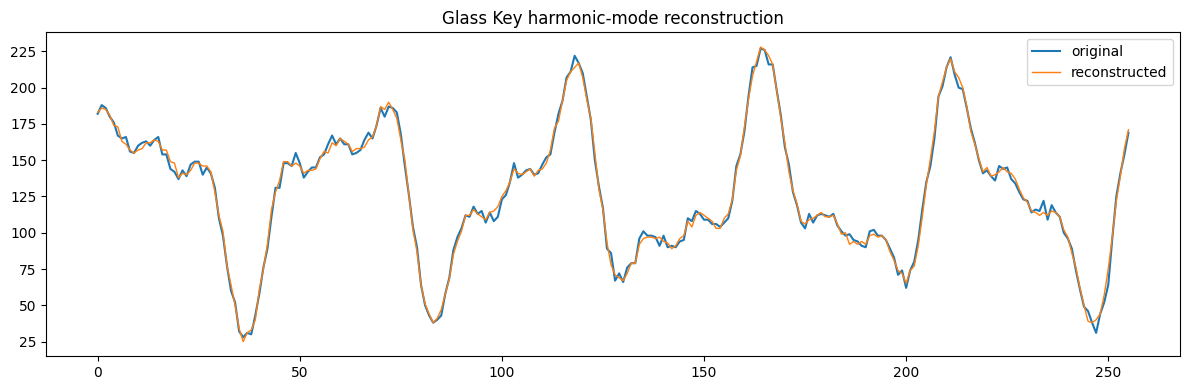

In [11]:

orig = bytes_to_signal(harmonic_data)
recon = bytes_to_signal(recon_h)

plt.figure(figsize=(12, 4))
plt.plot(orig, label="original", linewidth=1.5)
plt.plot(recon, label="reconstructed", linewidth=1.0)
plt.title("Glass Key harmonic-mode reconstruction")
plt.legend()
plt.tight_layout()
plt.show()



## Demo 2 — non-harmonic / random bytes

This should usually fail the harmonic score threshold and fall back to zlib.


In [12]:

rng = np.random.default_rng(1234)
random_data = rng.integers(0, 256, size=256, dtype=np.uint8).tobytes()
package_r = codec.compress(random_data)
package_r.mode, len(package_r.payload), package_r.harmonic_score


('zlib', 272, 2.6859745215090673)


## Inspect the seed and anchor layout


In [13]:

if package_h.mode == "glass":
    print("Mode byte:", package_h.payload[:1])
    print("Anchor bytes:", len(package_h.anchor))
    print("Seed bytes:", len(package_h.seed))
    print("Total package bytes:", len(package_h.payload))
    print("Seed (hex, first 24 bytes):", package_h.seed[:24].hex())
    print("Anchor digest (hex):", package_h.anchor[:32].hex())


Mode byte: b'G'
Anchor bytes: 64
Seed bytes: 48
Total package bytes: 113
Seed (hex, first 24 bytes): 02047705ffc80803ac0b99ec115b111b044d3004b73704ef
Anchor digest (hex): ea6337120a5f10b6a27dec69e7ef354ec982416caaf655d6635650ce1a8a5eb1



## Verification cell

The reconstruction is **attractor storage**, not general lossless compression.

Verification happens at two levels:

1. **Address integrity**: the anchor hash is fixed for the original bytes.
2. **Geometric fidelity**: correlation / relative $L^2$ error of the reconstruction.


In [14]:

original_digest = hashlib.sha256(harmonic_data).digest()
anchor_digest = package_h.anchor[:32] if package_h.mode == "glass" else b""
recon_digest = hashlib.sha256(recon_h).digest()

{
    "original_matches_anchor": original_digest == anchor_digest,
    "reconstruction_matches_anchor_exactly": recon_digest == anchor_digest,
    "harmonic_metrics": metrics_h,
}


{'original_matches_anchor': True,
 'reconstruction_matches_anchor_exactly': False,
 'harmonic_metrics': {'rmse': 3.0695072894521687,
  'corr': 0.9976247901148806,
  'rel_l2': 0.022753353768831572}}


## Placeholder seam: dual-channel SHA residue

The corpus also contains a **different** Glass Key line: a dual-channel SHA residue model where the hash is the static channel and the carries / residue history are the dynamic channel.

The code currently present in the uploaded corpus supports:
- NOP backbone
- residue against NOP
- double glass key
- lie detector
- removal cores

What it does **not** yet provide as runnable code is the fully specified:
- 48-byte Seed generator from the die’s carry geometry,
- 64-byte Anchor + Seed + recursive cross-correlation / IFFT unfold engine
- universal large-sequence rebirth path claimed in prose.

So the harmonic-mode compressor in this notebook is a **working notebook placeholder** for that larger architecture.


In [15]:

summary = {
    "harmonic_demo_mode": package_h.mode,
    "harmonic_demo_total_payload_bytes": len(package_h.payload),
    "harmonic_demo_score": package_h.harmonic_score,
    "harmonic_demo_metrics": metrics_h,
    "random_demo_mode": package_r.mode,
    "random_demo_total_payload_bytes": len(package_r.payload),
    "random_demo_score": package_r.harmonic_score,
    "die_hook_available": die_available,
    "die_hook_info": die_info,
}
summary


{'harmonic_demo_mode': 'glass',
 'harmonic_demo_total_payload_bytes': 113,
 'harmonic_demo_score': 43.28219300681587,
 'harmonic_demo_metrics': {'rmse': 3.0695072894521687,
  'corr': 0.9976247901148806,
  'rel_l2': 0.022753353768831572},
 'random_demo_mode': 'zlib',
 'random_demo_total_payload_bytes': 272,
 'random_demo_score': 2.6859745215090673,
 'die_hook_available': True,
 'die_hook_info': {'ground_witness': '0x8909ae5',
  'D_word': 4,
  'D_bit': 6,
  'waist_width': 2}}